# Import libraries

In [ ]:
import os
import warnings
import bisect
import gc
from copy import deepcopy
from collections import defaultdict

import psutil
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from kaggle.api.kaggle_api_extended import KaggleApi
from feature_engine.selection import DropConstantFeatures, DropDuplicateFeatures
from feature_engine.variable_handling import (
    find_categorical_variables,
    find_numerical_variables,
)

from kvbiii_plots.eda.categorical_plots import CategoricalPlots
from kvbiii_plots.eda.continuous_plots import ContinuousPlots
from kvbiii_plots.evaluation.regression_plots import RegressionPlots

from kvbiii_ml.data_processing.eda.data_analysis import DataAnalyzer
from kvbiii_ml.data_processing.eda.data_transformation import DataTransformer
from kvbiii_ml.data_processing.feature_engineering.case_normalizer import CaseNormalizer
from kvbiii_ml.data_processing.feature_engineering.categorical_aligner import CategoricalAligner
from kvbiii_ml.data_processing.feature_engineering.numerical_downcaster import NumericalDowncaster
from kvbiii_ml.data_processing.preprocessing.pipeline_dependency import build_restricted_pipeline

from kvbiii_ml.modeling.training.cross_validation import CrossValidationTrainer
from kvbiii_ml.modeling.training.ensemble_model import EnsembleModel
from kvbiii_ml.modeling.optimization.ensemble_weights_tuner import EnsembleWeightTunerCV
from kvbiii_ml.evaluation.generate_reports import regression_results

warnings.filterwarnings("ignore", category=UserWarning, message="Could not infer format")

data_analyzer = DataAnalyzer()
data_transformer = DataTransformer()
categorical_plots = CategoricalPlots()
continuous_plots = ContinuousPlots()
regression_plots = RegressionPlots()

SEED = 17
PROBLEM_TYPE = "regression"
METRIC_NAME = "RMSE"
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)
N_TRIALS = 100

cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, cv=CV, verbose=False)

# Load dataset

In [2]:
def load_data(folder_name: str = "data") -> tuple[pd.DataFrame, pd.DataFrame]:
    """Loads the train and test datasets from the specified folder."""
    train_csv = os.path.join(folder_name, "train.csv")
    test_csv = os.path.join(folder_name, "test.csv")
    train_df = pd.read_csv(train_csv, index_col="Id")
    test_df = pd.read_csv(test_csv, index_col="Id")
    return train_df, test_df


COMPETITION_NAME = "house-prices-advanced-regression-techniques"
train, test = load_data()
# train = train.sample(1000, random_state=SEED).reset_index(drop=True)
TARGET_FEATURE, train_data, test_data = "SalePrice", train, test
train_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


# Feature Engineering

In [3]:
train_data.columns = [ feature.upper().replace(" ", "_") for feature in train_data.columns ]
test_data.columns = [feature.upper().replace(" ", "_") for feature in test_data.columns]
features = train_data.columns.tolist()
features = [ (feature.upper().replace(" ", "_"), train_data[feature].dtype) for feature in features ]
TARGET_FEATURE = TARGET_FEATURE.upper().replace(" ", "_")

## Target Log Transformation

In [4]:
train_data[TARGET_FEATURE] = np.log1p(train_data[TARGET_FEATURE])

In [5]:
NUNIQUE_BIN_THRESHOLDS = (10, 100, 500)


def get_feature_groups(
    data: pd.DataFrame, target_feature: str
) -> tuple[list[str], list[str], list[str]]:
    """
    Splits a DataFrame's columns into independent, categorical, and numerical feature groups.

    Args:
        data (pd.DataFrame): The full dataset, including the target column.
        target_feature (str): Name of the target column to exclude from the feature groups.

    Returns:
        tuple[list[str], list[str], list[str]]: Independent, categorical, and numerical features.

    Raises:
        AssertionError: If categorical and numerical features do not together cover all
            independent features.
    """
    independent_feats = data.drop(columns=[target_feature]).columns.tolist()
    categorical_feats = find_categorical_variables(data[independent_feats], return_empty=True)
    numerical_feats = find_numerical_variables(data[independent_feats], return_empty=True)

    if set(categorical_feats) | set(numerical_feats) != set(independent_feats):
        raise AssertionError(
            "Categorical and numerical features do not cover all independent features."
        )

    return independent_feats, categorical_feats, numerical_feats

def group_features_by_n_bins(data: pd.DataFrame, features: list[str]) -> dict[int, list[str]]:
    """
    Groups numerical features by every quantile bin count their cardinality supports.

    A feature qualifies for a bin count `n_bins` (drawn from `NUNIQUE_BIN_THRESHOLDS`) whenever
    its cardinality is at least `n_bins`, so a high-cardinality feature can be discretised at
    several granularities at once (e.g. 13214 unique values qualifies for 10, 100, and 500 bins).
    A feature below the smallest threshold qualifies for none and is left unbinned.

    Args:
        data (pd.DataFrame): The dataset containing `features`.
        features (list[str]): Numerical feature names to group.

    Returns:
        dict[int, list[str]]: Quantile bin count mapped to the features that qualify for it.
    """
    features_by_n_bins: dict[int, list[str]] = defaultdict(list)
    features_with_nans = []
    for train_index, _ in CV.split(data, data[TARGET_FEATURE]):
        X_train_cv = data.iloc[train_index]
        features_with_nans.append(X_train_cv[features].columns[X_train_cv[features].isnull().all()].tolist())
    features_with_nans = list(set([item for sublist in features_with_nans for item in sublist]))
    features = [feature for feature in features if feature not in features_with_nans]
    for feature in features:
        nunique = data[feature].nunique(dropna=False)
        n_qualifying = bisect.bisect_right(NUNIQUE_BIN_THRESHOLDS, nunique)
        for n_bins in NUNIQUE_BIN_THRESHOLDS[:n_qualifying]:
            features_by_n_bins[n_bins].append(feature)
    features_by_n_bins = dict(features_by_n_bins)
    features_by_n_bins["low_variance_numerical_features"] = [feature for feature in features if feature not in features_by_n_bins[10]]
    return features_by_n_bins


independent_features, categorical_features, numerical_features = get_feature_groups(train_data, TARGET_FEATURE)
features_by_n_bins = group_features_by_n_bins(train_data, numerical_features)

## Initial preprocessing pipeline

In [6]:
initial_preprocessing_pipeline = Pipeline(
    steps=[
        ("numerical_downcaster", NumericalDowncaster(numerical_features)),
        (
            "case_normalizer",
            CaseNormalizer(features_names=categorical_features, normalization="upper"),
        ),
    ]
)

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train = initial_preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test = initial_preprocessing_pipeline.transform(X=X_test)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = (
    pd.concat([X_test, test_data[TARGET_FEATURE]], axis=1)
    if TARGET_FEATURE in test_data.columns
    else X_test.copy()
)
independent_features, categorical_features, numerical_features = get_feature_groups(train_data, TARGET_FEATURE)
features_by_n_bins = group_features_by_n_bins(train_data, numerical_features)
train_data

/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklearn/utils/_set_output.py:319: UserWarning: Failed to downcast column 'BSMTFINSF1' to <class 'numpy.int16'>: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
  data_to_wrap = f(self, X, *args, **kwargs)
/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklearn/utils/_set_output.py:319: UserWarning: Failed to downcast column 'BSMTFINSF2' to <class 'numpy.int16'>: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
  data_to_wrap = f(self, X, *args, **kwargs)
/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklear

,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,ALLEY,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,...,POOLAREA,POOLQC,FENCE,MISCFEATURE,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,0,<NA>,<NA>,<NA>,0,2,2008,WD,NORMAL,12.247699
2,20,RL,80.0,9600,PAVE,<NA>,REG,LVL,ALLPUB,FR2,...,0,<NA>,<NA>,<NA>,0,5,2007,WD,NORMAL,12.109016
3,60,RL,68.0,11250,PAVE,<NA>,IR1,LVL,ALLPUB,INSIDE,...,0,<NA>,<NA>,<NA>,0,9,2008,WD,NORMAL,12.317171
4,70,RL,60.0,9550,PAVE,<NA>,IR1,LVL,ALLPUB,CORNER,...,0,<NA>,<NA>,<NA>,0,2,2006,WD,ABNORML,11.849405
5,60,RL,84.0,14260,PAVE,<NA>,IR1,LVL,ALLPUB,FR2,...,0,<NA>,<NA>,<NA>,0,12,2008,WD,NORMAL,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,0,<NA>,<NA>,<NA>,0,8,2007,WD,NORMAL,12.072547
1457,20,RL,85.0,13175,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,0,<NA>,MNPRV,<NA>,0,2,2010,WD,NORMAL,12.254868
1458,70,RL,66.0,9042,PAVE,<NA>,REG,LVL,ALLPUB,INSIDE,...,0,<NA>,GDPRV,SHED,2500,5,2010,WD,NORMAL,12.493133


## Automated feature engineering pipeline

In [7]:
preprocessing_pipeline = Pipeline(
    steps=[
        (
            "categorical_aligner",
            CategoricalAligner(
                categorical_features=categorical_features,
                fill_strategy="constant",
                default_value="MISSING",
                warn_on_unknown=False
            ),
        ),
        (
            "numerical_downcaster",
            NumericalDowncaster()
        )
    ]
)

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train_transformed = preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test_transformed = preprocessing_pipeline.transform(X=X_test)
print(f"Number of features after preprocessing: {X_train_transformed.shape[1]}")

Number of features after preprocessing: 79


/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklearn/utils/_set_output.py:319: UserWarning: Failed to downcast column 'BSMTFINSF1' to <class 'numpy.int16'>: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
  data_to_wrap = f(self, X, *args, **kwargs)
/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklearn/utils/_set_output.py:319: UserWarning: Failed to downcast column 'BSMTFINSF2' to <class 'numpy.int16'>: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
  data_to_wrap = f(self, X, *args, **kwargs)
/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklear

## Drop constant and duplicated features

In [ ]:
def extract_source_features(columns: list[str], suffix: str) -> list[str]:
    """
    Recover the source feature names that produced derived columns ending in ``suffix``.


    Uses ``str.endswith`` rather than ``str.split`` so feature names that happen to
    contain the suffix string internally are handled correctly.

    Args:
        columns (list[str]): Column names from the post-transformation DataFrame.
        suffix (str): The full column suffix to match, e.g. ``"_PREPROCESS_WINSORIZER"``.

    Returns:
        list[str]: Sorted, deduplicated list of source feature names.
    """
    return sorted({col[: -len(suffix)] for col in columns if col.endswith(suffix)})


drop_features_pipeline = Pipeline(
    steps=[
        ("drop_constant_features", DropConstantFeatures(missing_values="ignore")),
        ("drop_duplicate_features", DropDuplicateFeatures()),
    ]
)
X_train_final = drop_features_pipeline.fit_transform(X_train_transformed, y_train)
X_test_final = drop_features_pipeline.transform(X_test_transformed)

surviving_features = sorted(set(X_train_final.columns) & set(X_test_final.columns))
X_train_final = X_train_final[surviving_features].copy()
X_test_final = X_test_final[surviving_features].copy()
print(f"Features after dropping constant and duplicates: {len(surviving_features)} / {X_train_transformed.shape[1]} ({len(surviving_features) / X_train_transformed.shape[1]:.1%})")

preprocessing_pipeline = build_restricted_pipeline(preprocessing_pipeline, X_train, y=y_train, selected_features=surviving_features)
original_input_surviving_features = sorted(set(independent_features) & set(preprocessing_pipeline[0].kw_args['features']))
train_data = train_data[original_input_surviving_features + [TARGET_FEATURE]].copy()
test_data = test_data[original_input_surviving_features + [TARGET_FEATURE]].copy() if TARGET_FEATURE in test_data.columns else test_data[original_input_surviving_features].copy()

Features after dropping constant and duplicates: 79 / 79 (100.0%)


In [9]:
independent_features, categorical_features, numerical_features = get_feature_groups(train_data, TARGET_FEATURE)
features_by_n_bins = group_features_by_n_bins(train_data, numerical_features)

## Memory reduction

In [11]:
def print_memory_usage(stage: str) -> None:
    """
    Print process and system memory usage in a readable format.

    Args:
        stage (str): Label describing when the snapshot is taken.
    """
    process = psutil.Process()
    rss_mb = process.memory_info().rss / (1024**2)
    virtual_memory = psutil.virtual_memory()
    available_mb = virtual_memory.available / (1024**2)
    print(f"[{stage}] Process RSS: {rss_mb:,.2f} MB | " f"Available RAM: {available_mb:,.2f} MB | " f"RAM used: {virtual_memory.percent:.1f}%")

def convert_category_to_object(dataframe: pd.DataFrame, dataframe_name: str) -> int:
    """
    Convert all category columns in a dataframe to object and print conversion details.

    Args:
        dataframe (pd.DataFrame): Dataframe to update.
        dataframe_name (str): Friendly dataframe name for logs.

    Returns:
        int: Number of converted columns.
    """
    category_columns = dataframe.select_dtypes(include=["category"]).columns.tolist()

    if not category_columns:
        print(f"{dataframe_name}: no 'category' columns found.")
        return 0

    dataframe[category_columns] = dataframe[category_columns].astype("object")
    print(f"{dataframe_name}: converted {len(category_columns)} column(s) " f"from 'category' to 'object': {category_columns}")
    return len(category_columns)

print_memory_usage("Before conversion")
train_converted_count = convert_category_to_object(train_data, "train_data")
test_converted_count = convert_category_to_object(test_data, "test_data")
print(f"Total converted columns: {train_converted_count + test_converted_count} " f"(train={train_converted_count}, test={test_converted_count})")
collected_objects = gc.collect()
print(f"Garbage collector reclaimed {collected_objects:,} unreachable object(s).")
print_memory_usage("After conversion")

[Before conversion] Process RSS: 369.62 MB | Available RAM: 54,944.31 MB | RAM used: 14.3%
train_data: no 'category' columns found.
test_data: no 'category' columns found.
Total converted columns: 0 (train=0, test=0)
Garbage collector reclaimed 48 unreachable object(s).
[After conversion] Process RSS: 369.62 MB | Available RAM: 54,946.98 MB | RAM used: 14.3%


# Summary of data analysis

In [12]:
data_analyzer.base_information(train_data)

,Feature,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,1STFLRSF,int16,0,0.00%,753,"1,460"
1,2NDFLRSF,int16,0,0.00%,417,"1,460"
2,3SSNPORCH,int16,0,0.00%,20,"1,460"
3,ALLEY,string,"1,369",93.77%,2,91
4,BEDROOMABVGR,int8,0,0.00%,8,"1,460"
5,BLDGTYPE,string,0,0.00%,5,"1,460"
6,BSMTCOND,string,37,2.53%,4,"1,423"
7,BSMTEXPOSURE,string,38,2.60%,4,"1,422"
8,BSMTFINSF1,int16,0,0.00%,637,"1,460"
9,BSMTFINSF2,int16,0,0.00%,144,"1,460"


# Baseline modeling

In [13]:
cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, preprocessing_pipeline=preprocessing_pipeline, cv=CV, verbose=True)

### LightGBM

In [14]:
lgbm_model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=80,
    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,
    reg_alpha=0.15,
    reg_lambda=1.50,
    max_bin=255,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
    deterministic=True,
    force_col_wise=True,
    importance_type="gain",
    early_stopping_round=100
)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=lgbm_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

[50]	training's rmse: 0.181686	valid_1's rmse: 0.193527
[100]	training's rmse: 0.132133	valid_1's rmse: 0.151602
[150]	training's rmse: 0.117679	valid_1's rmse: 0.141859
[200]	training's rmse: 0.109742	valid_1's rmse: 0.1388
[250]	training's rmse: 0.103821	valid_1's rmse: 0.137283
[300]	training's rmse: 0.099058	valid_1's rmse: 0.136673
[350]	training's rmse: 0.0949008	valid_1's rmse: 0.13599
[400]	training's rmse: 0.0912952	valid_1's rmse: 0.135635
[450]	training's rmse: 0.0880909	valid_1's rmse: 0.134619
[500]	training's rmse: 0.0850416	valid_1's rmse: 0.134736
[550]	training's rmse: 0.0822044	valid_1's rmse: 0.134309
[600]	training's rmse: 0.0795667	valid_1's rmse: 0.134068
[650]	training's rmse: 0.0770708	valid_1's rmse: 0.1342
[700]	training's rmse: 0.074717	valid_1's rmse: 0.133891
[750]	training's rmse: 0.0726647	valid_1's rmse: 0.133483
[800]	training's rmse: 0.0706131	valid_1's rmse: 0.133453
[850]	training's rmse: 0.0687585	valid_1's rmse: 0.133706
Fold 1: train=0.07151 | val

### XGBoost

In [15]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=6.0,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.05,
    reg_lambda=2.0,
    gamma=0.0,
    max_bin=256,
    enable_categorical=True,
    tree_method="hist",
    device="cuda",
    random_state=SEED,
    n_jobs=-1,
    early_stopping_rounds=50,
)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=xgb_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

[0]	validation_0-rmse:0.38936	validation_1-rmse:0.39118
[50]	validation_0-rmse:0.13504	validation_1-rmse:0.17906
[100]	validation_0-rmse:0.06795	validation_1-rmse:0.14252
[150]	validation_0-rmse:0.04632	validation_1-rmse:0.13494
[200]	validation_0-rmse:0.03679	validation_1-rmse:0.13286
[250]	validation_0-rmse:0.03154	validation_1-rmse:0.13192
[300]	validation_0-rmse:0.02705	validation_1-rmse:0.13133
[350]	validation_0-rmse:0.02321	validation_1-rmse:0.13105
[400]	validation_0-rmse:0.01990	validation_1-rmse:0.13080
[450]	validation_0-rmse:0.01704	validation_1-rmse:0.13068
[500]	validation_0-rmse:0.01456	validation_1-rmse:0.13063
[518]	validation_0-rmse:0.01379	validation_1-rmse:0.13064
Fold 1: train=0.01606 | valid=0.13059
[0]	validation_0-rmse:0.39125	validation_1-rmse:0.38375
[50]	validation_0-rmse:0.13651	validation_1-rmse:0.16691
[100]	validation_0-rmse:0.06896	validation_1-rmse:0.13579
[150]	validation_0-rmse:0.04700	validation_1-rmse:0.13245
[200]	validation_0-rmse:0.03745	validati

### CatBoost

In [16]:
catboost_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=SEED,
    cat_features=categorical_features,
    task_type="GPU",
    iterations = 11000,
    early_stopping_rounds = 500,
    allow_writing_files=False,
    verbose=0,
    learning_rate = 0.015,
    depth = 8,
    l2_leaf_reg = 8.5,
    random_strength = 0.65,
    bagging_temperature = 0.45,
    bootstrap_type = "Bayesian",
    grow_policy = "SymmetricTree",
    border_count = 254,
    one_hot_max_size = 10,
    min_data_in_leaf = 48,
    max_ctr_complexity = 4,
)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=catboost_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

0:	learn: 0.3953000	test: 0.3963725	best: 0.3963725 (0)	total: 25.6ms	remaining: 4m 41s
50:	learn: 0.2580659	test: 0.2633498	best: 0.2633498 (50)	total: 1.08s	remaining: 3m 51s
100:	learn: 0.1906461	test: 0.1988264	best: 0.1988264 (100)	total: 2.07s	remaining: 3m 43s
150:	learn: 0.1573124	test: 0.1682486	best: 0.1682486 (150)	total: 3.07s	remaining: 3m 40s
200:	learn: 0.1387991	test: 0.1526964	best: 0.1526964 (200)	total: 4.04s	remaining: 3m 36s
250:	learn: 0.1275382	test: 0.1446855	best: 0.1446855 (250)	total: 5.08s	remaining: 3m 37s
300:	learn: 0.1197851	test: 0.1400267	best: 0.1400267 (300)	total: 6.09s	remaining: 3m 36s
350:	learn: 0.1144824	test: 0.1371238	best: 0.1371238 (350)	total: 7.15s	remaining: 3m 36s
400:	learn: 0.1099746	test: 0.1348932	best: 0.1348932 (400)	total: 8.19s	remaining: 3m 36s
450:	learn: 0.1063344	test: 0.1334257	best: 0.1334257 (450)	total: 9.22s	remaining: 3m 35s
500:	learn: 0.1030544	test: 0.1322054	best: 0.1322054 (500)	total: 10.3s	remaining: 3m 34s
550:

### Ensemble model

In [17]:
cross_validation_trainer = CrossValidationTrainer(metric_name=METRIC_NAME, problem_type=PROBLEM_TYPE, preprocessing_pipeline=preprocessing_pipeline, cv=CV, verbose=False)

In [18]:
estimators = [lgbm_model, xgb_model, catboost_model]

ensemble_model = EnsembleModel(estimators=estimators, problem_type=PROBLEM_TYPE)
train_scores, valid_scores, _ = cross_validation_trainer.fit(estimator=ensemble_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE])
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}")

Train RMSE: 0.0485 +- 0.0055
Validation RMSE: 0.1220 +- 0.0063


In [19]:
ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators=estimators,
    cross_validator=cross_validation_trainer,
    n_trials=N_TRIALS * 5,
    seed=SEED,
    allow_negative_weights=False,
)
ensemble_weights_tuner.tune(
    train_data[independent_features], train_data[TARGET_FEATURE]
)
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(
        f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}"
    )

🔍 Starting ensemble weight search with 500 trials via cross-validation, target metric: RMSE (minimize).
🎛️  Blending 3 estimators: ['LGBMRegressor', 'XGBRegressor', 'CatBoostRegressor']
[EnsembleWeightTunerCV] LGBMRegressor OOF RMSE: 0.12973 +- 0.00792
[EnsembleWeightTunerCV] XGBRegressor OOF RMSE: 0.12896 +- 0.00583
[EnsembleWeightTunerCV] CatBoostRegressor OOF RMSE: 0.12535 +- 0.00748
🌟 Trial 1/500 | RMSE: 0.125270 | Best: 0.125270 (trial 1) | 0.00s | weights: [0.3333, 0.3333, 0.3333]
🔁 Trial 2/500 | RMSE: 0.133689 | Best: 0.125270 (trial 1) | 0.00s | weights: [1.0, 0.0, 0.0]
🔁 Trial 3/500 | RMSE: 0.131871 | Best: 0.125270 (trial 1) | 0.00s | weights: [0.0, 1.0, 0.0]
🔁 Trial 4/500 | RMSE: 0.129094 | Best: 0.125270 (trial 1) | 0.00s | weights: [0.0, 0.0, 1.0]
🔁 Trial 5/500 | RMSE: 0.126466 | Best: 0.125270 (trial 1) | 0.00s | weights: [0.2898, 0.5218, 0.1884]
🔁 Trial 6/500 | RMSE: 0.125909 | Best: 0.125270 (trial 1) | 0.00s | weights: [0.0449, 0.5208, 0.4343]
🔁 Trial 7/500 | RMSE: 0.1

In [20]:
ensemble_model = EnsembleModel( estimators=ensemble_weights_tuner.estimators, problem_type=PROBLEM_TYPE, weights=ensemble_weights_tuner.best_weights, )
train_scores, valid_scores, _ = cross_validation_trainer.fit( estimator=ensemble_model, X=train_data[independent_features], y=train_data[TARGET_FEATURE], )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

Train RMSE: 0.0525 +- 0.0059
Validation RMSE: 0.1216 +- 0.0065


In [21]:
final_model = ensemble_model

# Evaluation

In [22]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.1, random_state=SEED, shuffle=True)

In [23]:
X_train_temp = train_data_temp.drop(columns=[TARGET_FEATURE]).copy()
y_train_temp = train_data_temp[TARGET_FEATURE]
X_test_temp = test_data_temp.drop(columns=[TARGET_FEATURE], errors="ignore").copy()
y_test_temp = test_data_temp[TARGET_FEATURE] if TARGET_FEATURE in test_data_temp.columns else None

X_train_temp = preprocessing_pipeline.fit_transform(X=X_train_temp, y=y_train_temp)
X_test_temp = preprocessing_pipeline.transform(X=X_test_temp)

final_model.fit( X_train_temp, y_train_temp, eval_set=[(X_test_temp, y_test_temp)],)

y_train_pred = final_model.predict(X_train_temp)
y_test_pred = final_model.predict(X_test_temp)

In [24]:
regression_results(y_train_true=y_train_temp, y_train_pred=y_train_pred, y_test_true=y_test_temp, y_test_pred=y_test_pred)

,MAE,MedAE,MSE,RMSE,MAPE,R²,Explained Var
Train,0.0463,0.0347,0.0045,0.0672,0.39%,0.9716,0.9716
Test,0.0890,0.0601,0.0147,0.1211,0.74%,0.9108,0.9108


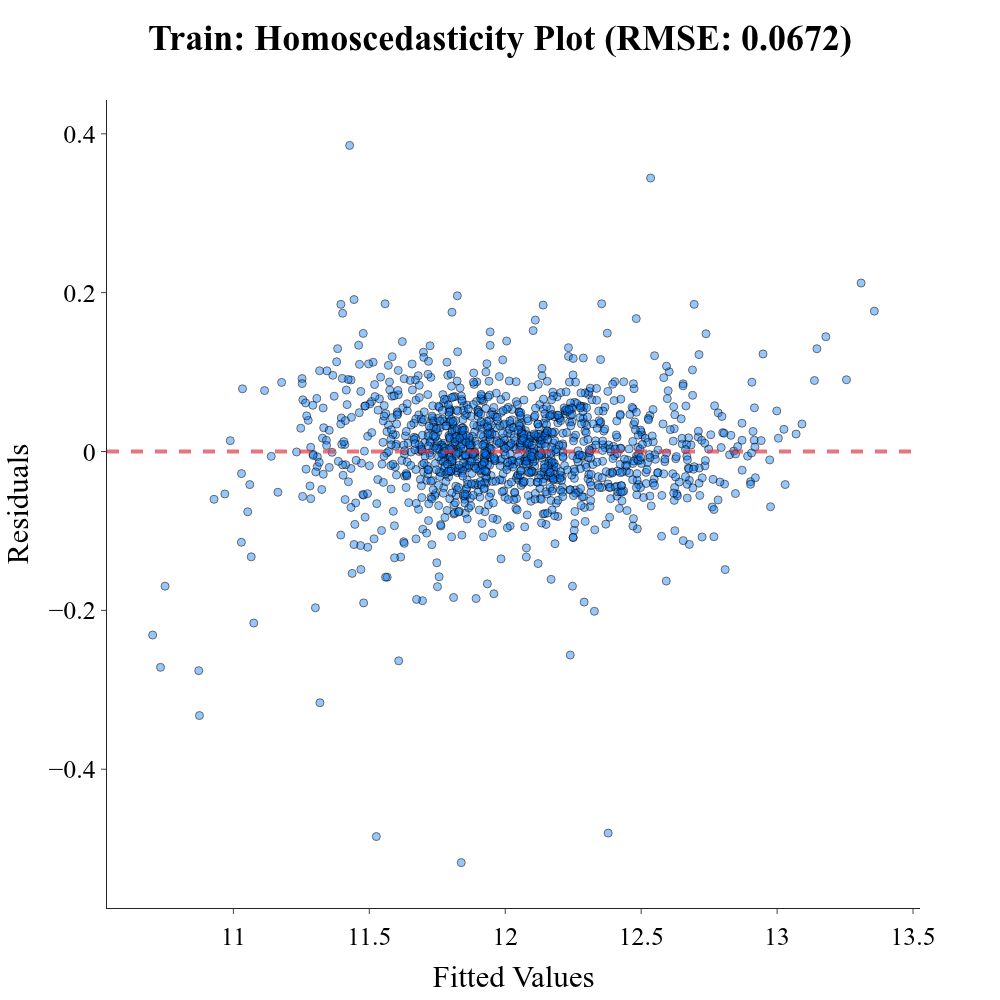

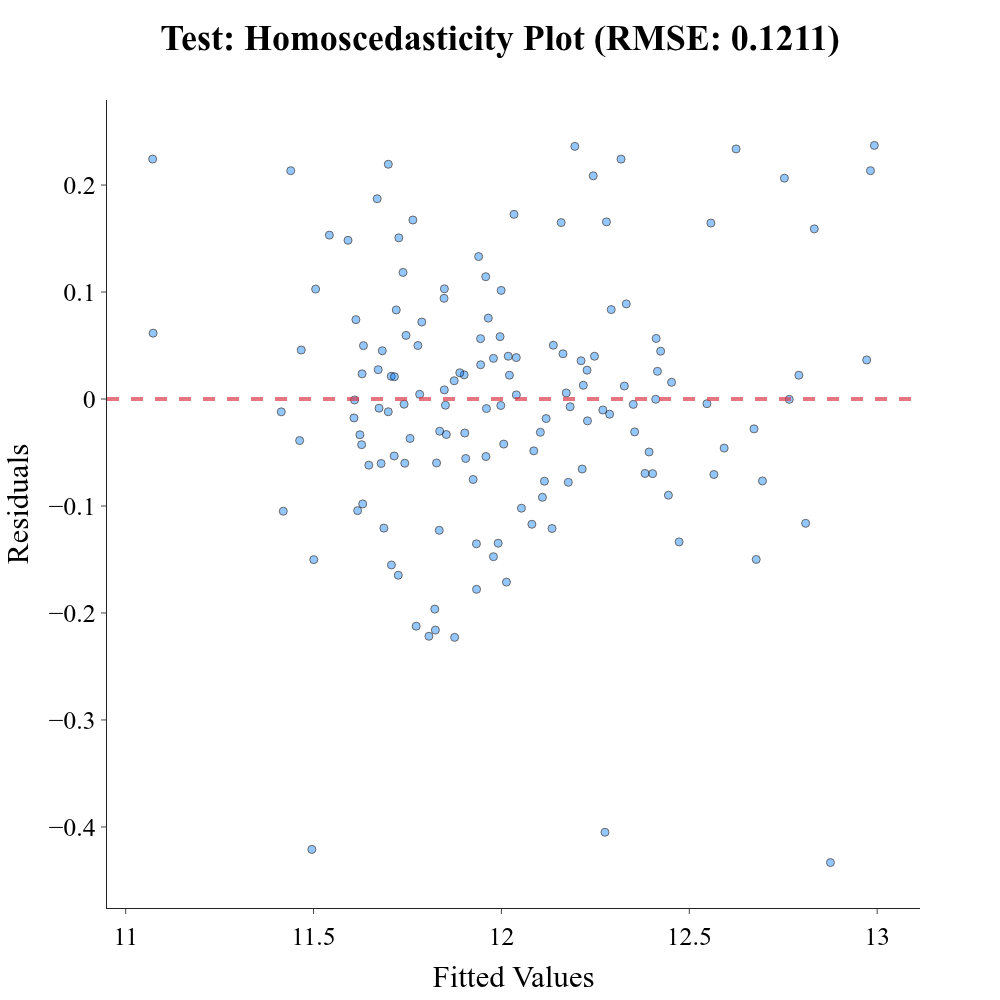

In [25]:
regression_plots.homoscedacity_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title=f"Train: Homoscedasticity Plot", metric_name="RMSE")
regression_plots.homoscedacity_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title=f"Test: Homoscedasticity Plot", metric_name="RMSE")

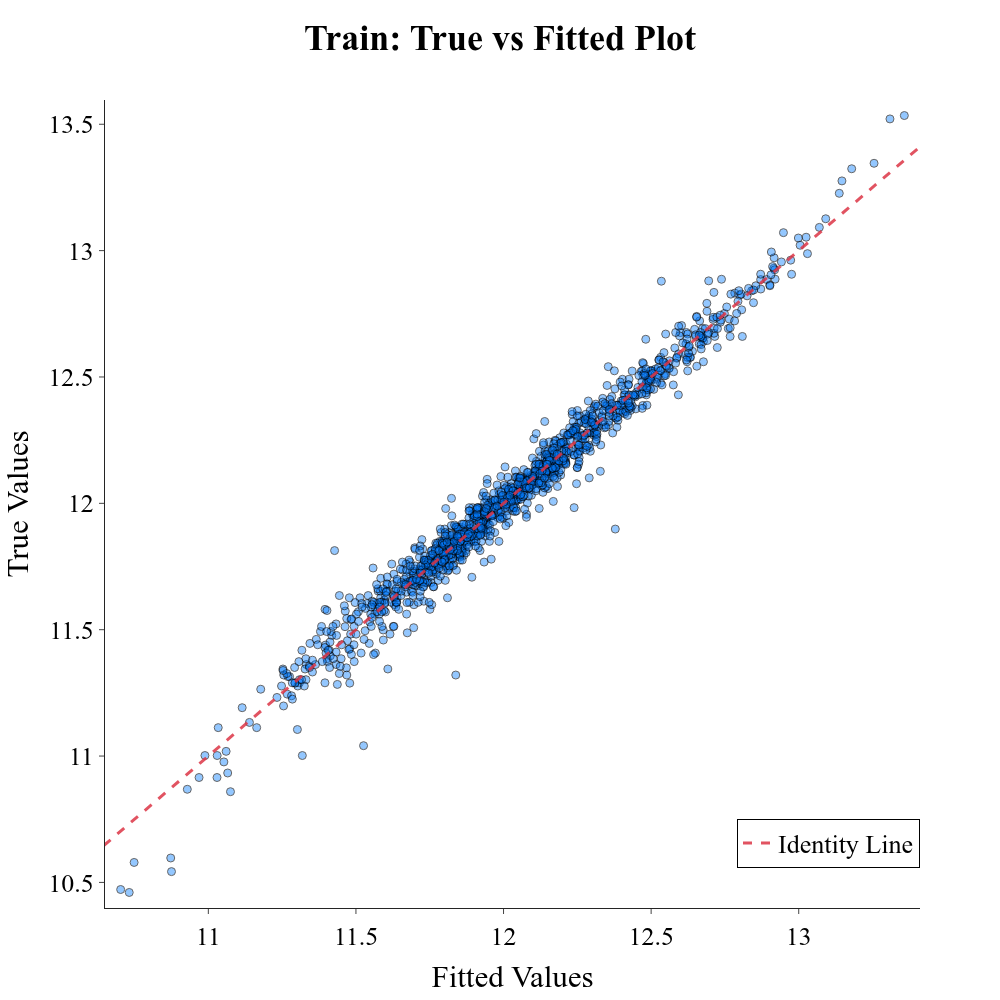

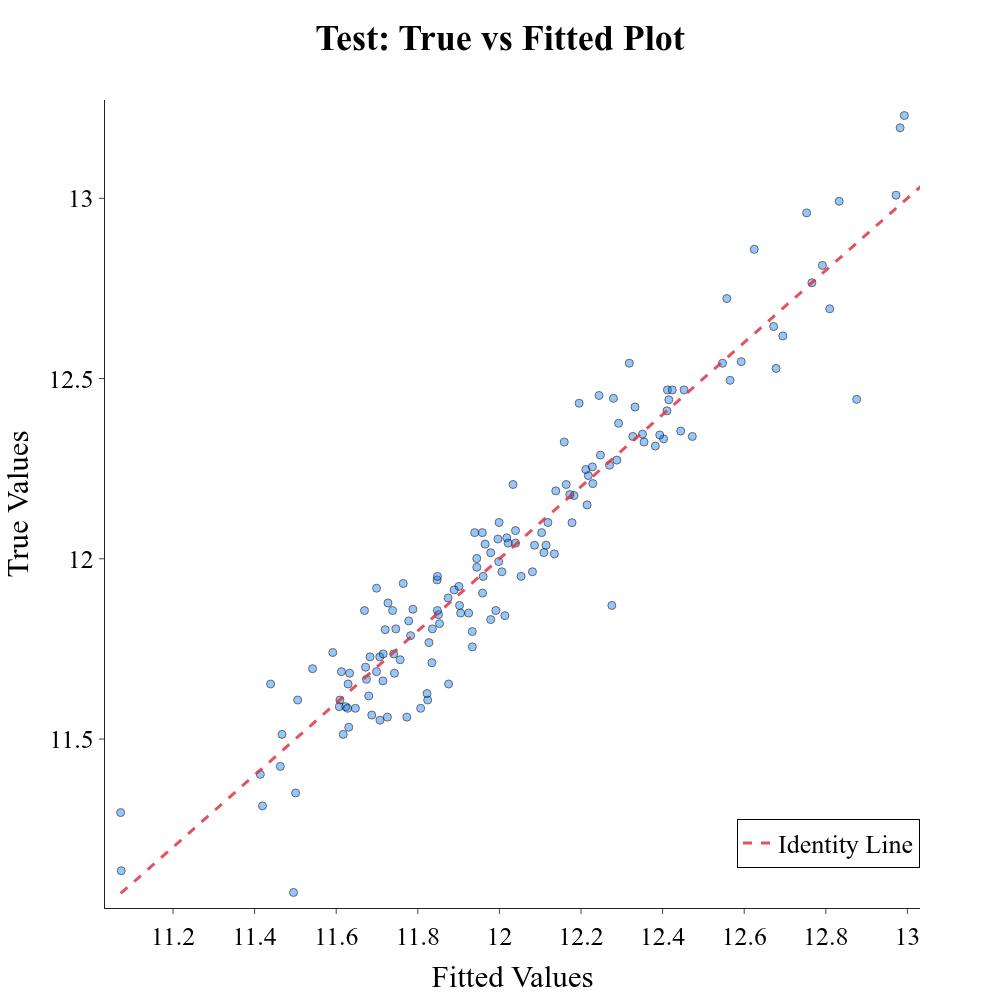

In [26]:
regression_plots.true_vs_fitted_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title=f"Train: True vs Fitted Plot", metric_name="RMSE")
regression_plots.true_vs_fitted_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title=f"Test: True vs Fitted Plot", metric_name="RMSE")

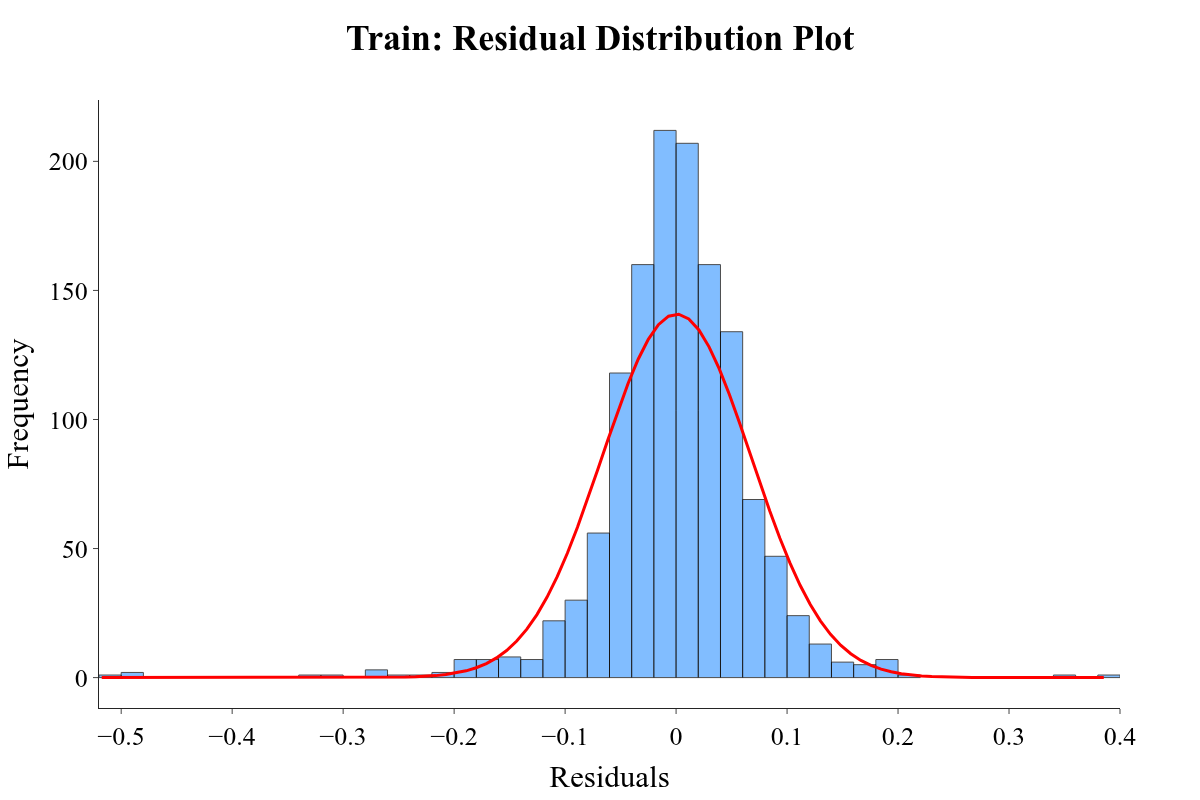

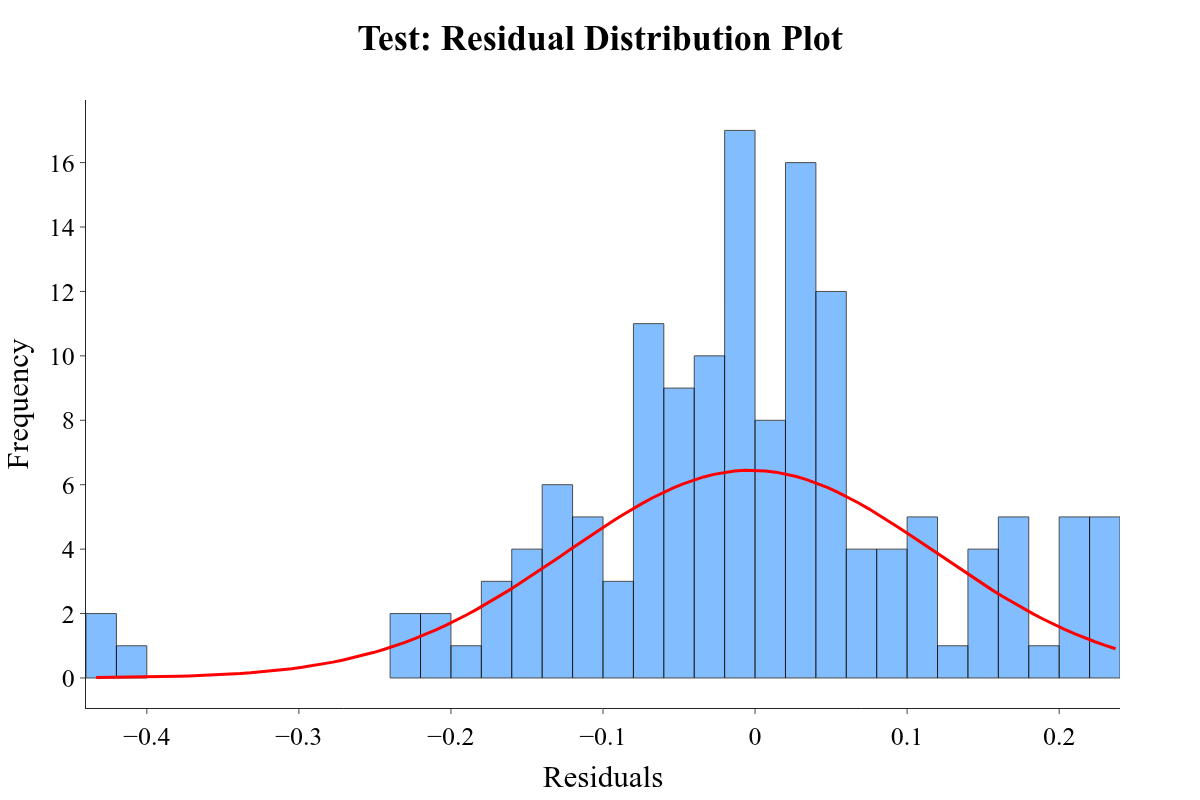

In [27]:
regression_plots.residual_distribution_plot(y_true=y_train_temp, y_pred=y_train_pred, plot_title=f"Train: Residual Distribution Plot", metric_name="RMSE")
regression_plots.residual_distribution_plot(y_true=y_test_temp, y_pred=y_test_pred, plot_title=f"Test: Residual Distribution Plot", metric_name="RMSE")

# Final Submission

In [29]:
def submit_to_kaggle(predictions: np.ndarray, submission_data: pd.DataFrame, competition_name: str, message: str = "Submission") -> None:
    """
    Submits predictions to a Kaggle competition.
    
    Args:
        predictions (np.ndarray): Array of predictions to submit.
        submission_data (pd.DataFrame): DataFrame containing the submission format.
        competition_name (str): Name of the Kaggle competition.
        message (str): Submission message.
    """
    api = KaggleApi()
    api.authenticate()
    submission_data[submission_data.columns[1]] = predictions
    submission_data.to_csv("submission.csv", index=False)
    api.competition_submit(file_name="submission.csv", message=message, competition=competition_name)
    display(submission_data.head())

submission_data = pd.read_csv("data/sample_submission.csv")

In [30]:
def inverse_transform_predictions(predictions: np.ndarray) -> np.ndarray:
    """
    Inverse transforms predictions that were log-transformed using np.log1p.
    
    Args:
        predictions (np.ndarray): Array of log-transformed predictions.
    
    Returns:
        np.ndarray: Array of predictions in the original scale.
    """
    return np.expm1(predictions)

## Submission (traditional approach)

/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklearn/utils/_set_output.py:319: UserWarning: Failed to downcast column 'BSMTFINSF1' to <class 'numpy.int16'>: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
  data_to_wrap = f(self, X, *args, **kwargs)
/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklearn/utils/_set_output.py:319: UserWarning: Failed to downcast column 'BSMTFINSF2' to <class 'numpy.int16'>: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
  data_to_wrap = f(self, X, *args, **kwargs)
/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklear

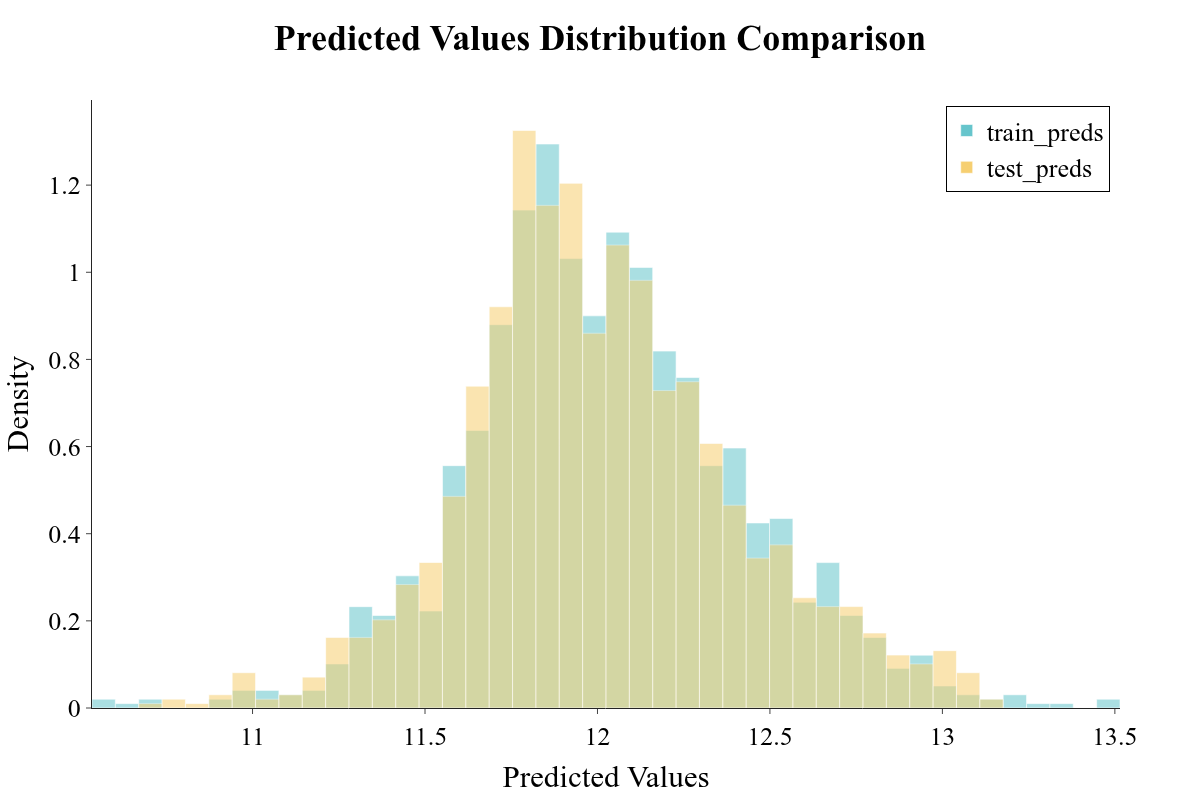

100%|██████████| 33.7k/33.7k [00:00<00:00, 76.5kB/s]


,Id,SalePrice
0,1461,124586.051932
1,1462,157547.509527
2,1463,185322.006942
3,1464,194022.271155
4,1465,186666.248957


In [31]:
def disable_early_stopping(estimator: object) -> object:
    """
    Disable early stopping for supported estimators.

    Args:
        estimator (object): The estimator to modify.

    Returns:
        object: The estimator with early stopping disabled.
    """
    if hasattr(estimator, "early_stopping_round"):
        estimator.set_params(early_stopping_round=None)
    elif hasattr(estimator, "early_stopping"):
        if "LGBM" in estimator.__class__.__name__:
            estimator.set_params(early_stopping=None)
        elif "HistGradientBoosting" in estimator.__class__.__name__:
            estimator.set_params(early_stopping=False)
    elif hasattr(estimator, "early_stopping_rounds"):
        estimator.set_params(early_stopping_rounds=None)
    return estimator

X_train = train_data.drop(columns=[TARGET_FEATURE]).copy()
y_train = train_data[TARGET_FEATURE]
X_test = test_data.drop(columns=[TARGET_FEATURE], errors="ignore").copy()

X_train_transformed = preprocessing_pipeline.fit_transform(X=X_train, y=y_train)
X_test_transformed = preprocessing_pipeline.transform(X=X_test)

final_model_no_early_stopping = deepcopy(final_model)
if hasattr(final_model_no_early_stopping, "estimators"):
    final_model_no_early_stopping.estimators = [ disable_early_stopping(est) for est in final_model_no_early_stopping.estimators ]
else:
    final_model_no_early_stopping = disable_early_stopping( final_model_no_early_stopping )

final_model_no_early_stopping.fit( X_train_transformed, y_train)
train_preds = final_model_no_early_stopping.predict( X_train_transformed )
test_preds = final_model_no_early_stopping.predict( X_test_transformed )
continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle( predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (traditional approach)", )

## Submission (validation set approach)

In [33]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.1, random_state=SEED, shuffle=True)
X_train_temp = train_data_temp.drop(columns=[TARGET_FEATURE]).copy()
y_train_temp = train_data_temp[TARGET_FEATURE]
X_test_temp = test_data_temp.drop(columns=[TARGET_FEATURE], errors="ignore").copy()
y_test_temp = test_data_temp[TARGET_FEATURE]

X_train_temp_transformed = preprocessing_pipeline.fit_transform(X=X_train_temp, y=y_train_temp)
X_test_temp_transformed = preprocessing_pipeline.transform(X=X_test_temp)

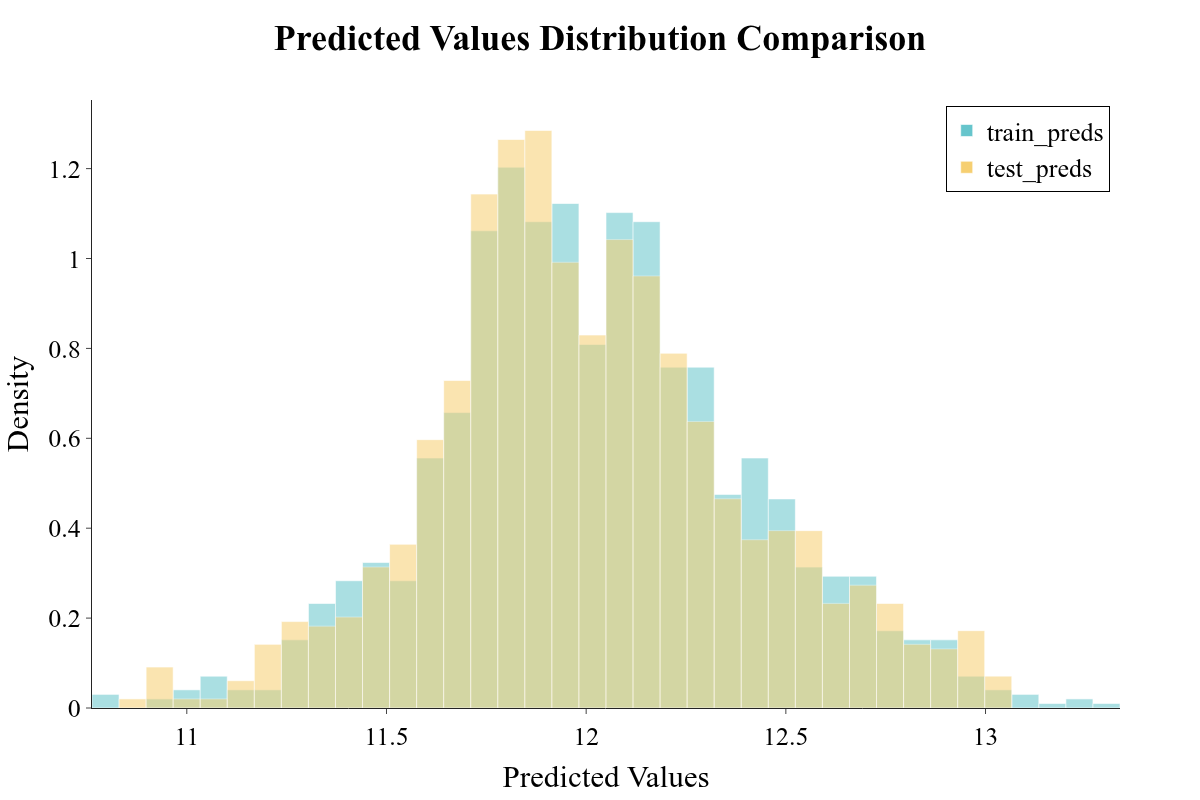

100%|██████████| 33.6k/33.6k [00:00<00:00, 68.6kB/s]


,Id,SalePrice
0,1461,128223.733244
1,1462,156192.616492
2,1463,184433.901722
3,1464,191998.765100
4,1465,188369.140846


In [35]:
final_model.fit( X_train_temp_transformed, y_train_temp, eval_set=[(X_test_temp_transformed, y_test_temp)])
train_preds = final_model.predict( X_train_transformed )
test_preds = final_model.predict( X_test_transformed )

continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle( predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (with early stopping)", )

## Submission (OOF approach)

/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklearn/utils/_set_output.py:319: UserWarning: Failed to downcast column 'BSMTFINSF1' to <class 'numpy.int16'>: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
  data_to_wrap = f(self, X, *args, **kwargs)
/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklearn/utils/_set_output.py:319: UserWarning: Failed to downcast column 'BSMTFINSF2' to <class 'numpy.int16'>: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')
  data_to_wrap = f(self, X, *args, **kwargs)
/home/kvbiii/Desktop/KubiK/Programming/Python/Kaggle_Competitions/Kaggle_Competitions_venv/lib/python3.14/site-packages/sklear

Train RMSE: 0.0525 +- 0.0059
Validation RMSE: 0.1216 +- 0.0065


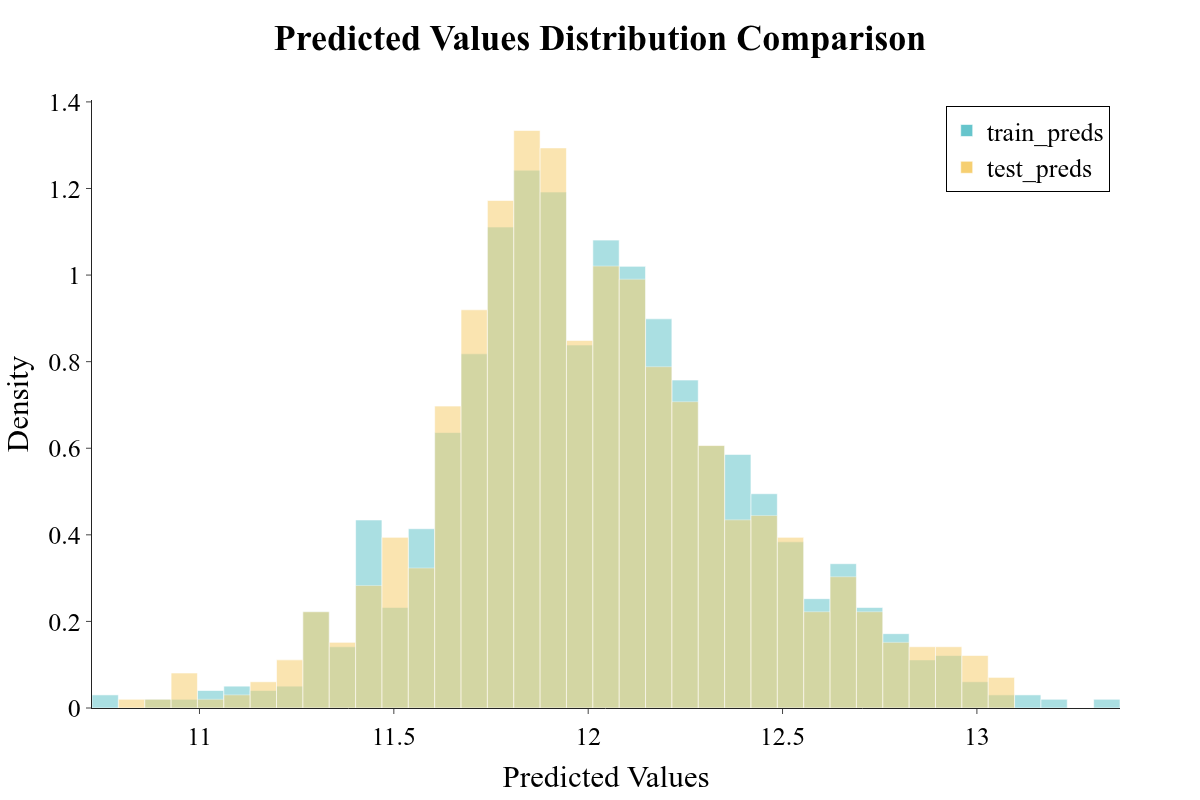

100%|██████████| 33.6k/33.6k [00:00<00:00, 80.0kB/s]


,Id,SalePrice
0,1461,125905.154333
1,1462,157835.257510
2,1463,185055.693969
3,1464,192026.944236
4,1465,188540.818233


In [36]:
cross_validation_trainer = CrossValidationTrainer(
    metric_name=METRIC_NAME,
    problem_type=PROBLEM_TYPE,
    preprocessing_pipeline=preprocessing_pipeline,
    cv=CV,
    verbose=False,
)

train_scores, valid_scores, avg_test_pred = cross_validation_trainer.fit( estimator=deepcopy(final_model), X=train_data[independent_features], y=train_data[TARGET_FEATURE], X_test=test_data[independent_features], )
print(f"Train {METRIC_NAME}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print( f"Validation {METRIC_NAME}: {np.mean(valid_scores):.4f} +- {np.std(valid_scores):.4f}" )

train_preds = cross_validation_trainer.predict(X=train_data[independent_features])
test_preds = avg_test_pred
continuous_plots.compare_distributions_plot(
    data={
        "train_preds": train_preds,
        "test_preds": test_preds
    },
    plot_title="Predicted Values Distribution Comparison",
    xaxis_title="Predicted Values",
    yaxis_title="Density"
)

submit_to_kaggle(predictions=inverse_transform_predictions(test_preds), submission_data=submission_data, competition_name=COMPETITION_NAME, message="Final Submission (OOF predictions)", )